In [1]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import scienceplots
import seaborn as sns

In [2]:
RESULTS_DF = "../data/results.parquet"

In [3]:
df = pd.read_parquet(RESULTS_DF)

In [4]:
# Use output_ebit_count if available, otherwise fallback to distribution_cost (which is reported in some timeout executions)
df["partition_ebit_cost"] = df["output_ebit_count"].fillna(df["distribution_cost"])

In [5]:
# Filter to only include partitioners of interest
PARTITIONERS = {
    "fgp-roee",
    "mlfm-r",
    "pytket-dqc-esd",
}

df = df[df["partitioner"].isin(PARTITIONERS)].copy()

In [6]:
# Rename network_topology values for consistency
df["network_topology"] = df["network_topology"].replace("mesh", "grid")

In [7]:
# Only keep results for 4 QPUs
df = df[df["num_qpus"] == 4].copy()

In [8]:
# Filter to only include experiments that have results for all partitioners

experiment_cols = ["circuit", "benchmark", "num_qpus"]
all_partitioners = sorted(df["partitioner"].dropna().unique())

valid_for_all_metrics = (
    df["partitioner"].notna()
    & df["n_qubits"].notna()
    & df["partition_exec_time_s"].notna()
    & df["partition_ebit_cost"].notna()
    & (df["input_circuit_depth"] > 0)
    & df["output_circuit_depth"].notna()
    & (df["input_gate_node_count"] > 0)
    & df["output_gate_node_count"].notna()
)

valid_groups = (
    df[valid_for_all_metrics]
    .groupby(experiment_cols)["partitioner"]
    .nunique()
    .reset_index(name="valid_partitioner_count")
)

complete_groups = valid_groups[
    valid_groups["valid_partitioner_count"] == len(all_partitioners)
][experiment_cols].copy()


df = df.merge(complete_groups, on=experiment_cols, how="inner")

print(
    f"Total experiments kept (complete across all partitioners): {len(complete_groups)}"
)

Total experiments kept (complete across all partitioners): 198


In [9]:
# Map partitioner names to more readable labels for plotting
PARTITIONER_LABEL_MAP = {
    "fgp-roee": "FGP-rOEE",
    "mlfm-r": "MLFM-R",
    "pytket-dqc-esd": "Pytket ESD",
}

df["partitioner"] = df["partitioner"].map(PARTITIONER_LABEL_MAP).fillna(df["partitioner"])
PARTITIONER_LABELS = [PARTITIONER_LABEL_MAP.get(p, p) for p in all_partitioners]

In [10]:
# Plotting configuration
METRICS = [
    "partition_ebit_cost",
]
METRIC_LABEL = {
    "partition_ebit_cost": "E-bit Cost",
}
NETWORK_TOPOLOGY_COLORS = {
    "linear": "#56B4E9",
    "grid": "#E69F00",
    "fully_connected": "#CC79A7",
}
NETWORK_TOPOLOGY_ORDER = [
    "linear",
    "grid",
    "fully_connected",
]


plt.style.use(["science", "ieee", "grid"])
matplotlib.rcParams.update(
    {
        "font.family": "serif",
        "text.usetex": True,
    }
)

COLUMN_WIDTH = 3.46
BETWEEN_COLUMN_SPACING = 0.14
ASPECT_RATIO = 3/5
SCALE = 1.0
FIGURE_WIDTH = COLUMN_WIDTH * SCALE
FIGURE_HEIGHT = FIGURE_WIDTH * ASPECT_RATIO

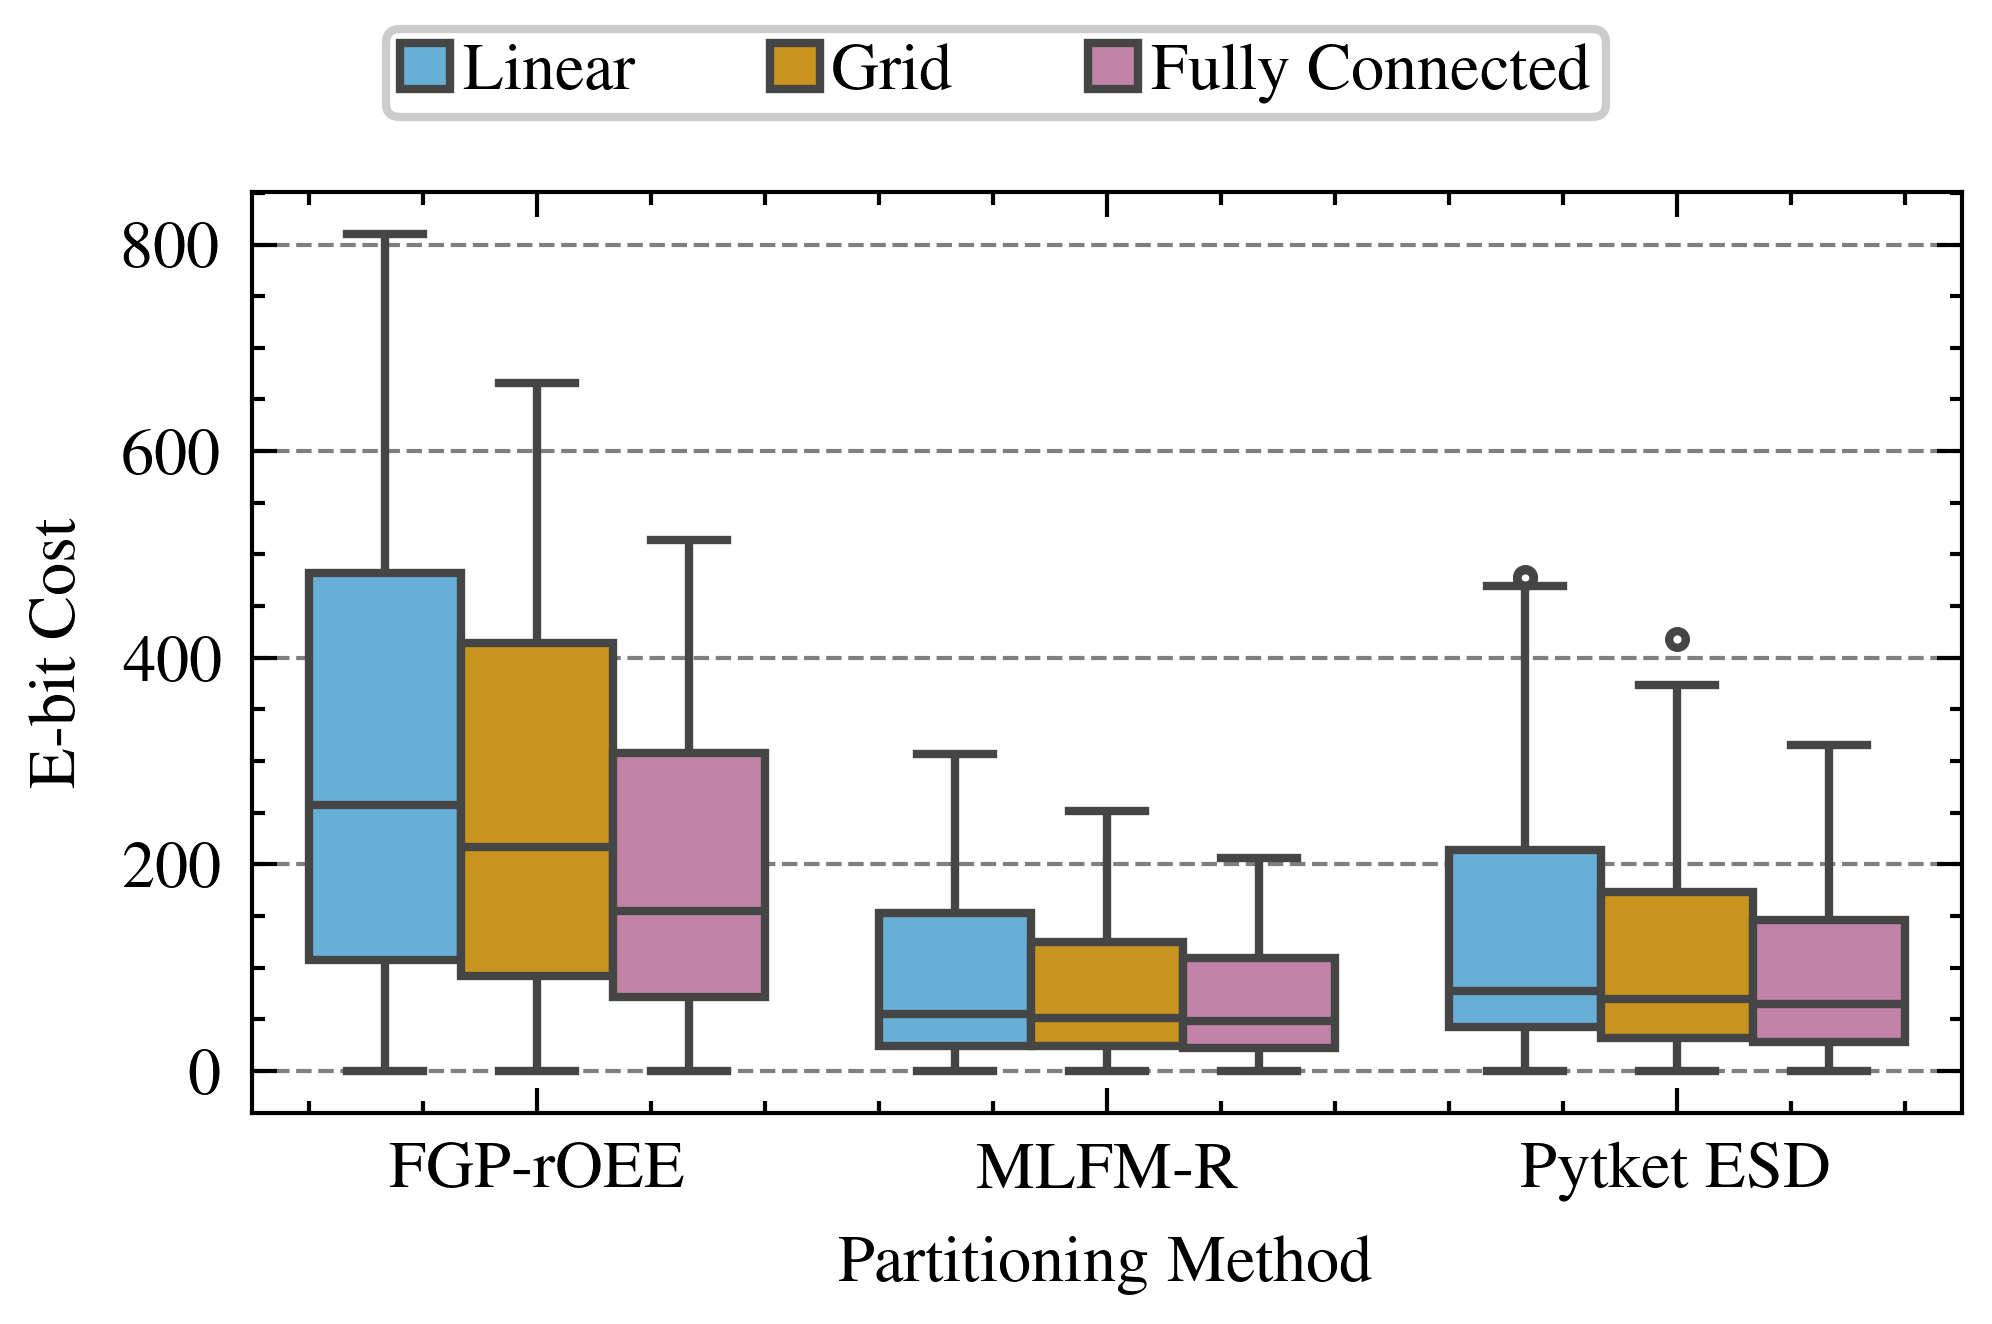

In [11]:
fig, axes = plt.subplots(
    len(METRICS), 1, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), sharex=True
)

if len(METRICS) == 1:
    axes = [axes]


for idx, metric in enumerate(METRICS):
    metric_df = df.copy()
    metric_df[metric] = pd.to_numeric(metric_df[metric], errors="coerce")
    metric_df = metric_df.dropna(subset=[metric])

    sns.boxplot(
        data=metric_df,
        x="partitioner",
        y=metric,
        hue="network_topology",
        order=PARTITIONER_LABELS,
        hue_order=NETWORK_TOPOLOGY_ORDER,
        palette=NETWORK_TOPOLOGY_COLORS,
        ax=axes[idx],
        fliersize=2,
        # width=0.6
    )

    axes[idx].set_ylabel(METRIC_LABEL[metric])

    axes[idx].tick_params(axis="x")#, rotation=15)
    if idx < len(METRICS) - 1:
        axes[idx].set_xlabel("")
        axes[idx].tick_params(axis="x", which="both", bottom=False, labelbottom=False)
    else:
        axes[idx].set_xlabel("Partitioning Method")

unique_handles_labels = {}
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        if label not in unique_handles_labels:
            unique_handles_labels[label] = handle
    if ax.get_legend():
        ax.get_legend().remove()

unique_handles_labels = {
    k.title().replace("_", " "): v for k, v in unique_handles_labels.items()
}

handles = list(unique_handles_labels.values())
labels = list(unique_handles_labels.keys())

fig.legend(
    handles,
    labels,
    # title="Network Topology",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=len(labels),
    frameon=True,
    handletextpad=0.2,
    # columnspacing=0.5,
    borderpad=0.2,
    labelspacing=0.3,
    handlelength=0.75,
    markerscale=0.75,
)

plt.tight_layout()
plt.savefig("figures/network_topology.pdf", bbox_inches="tight", dpi=300)
plt.show()